 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : John Ryan         <br>
Student Number : L00007202         <br>
Due Date       : 12th May 2026     <br>
Assignment     : CA2               <br>
Module         : AI for Vision and NLP    <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level
An image of your working pipeline at high level can be inserted here



## Install packages

In [1]:
pip install -r requirements_v4.txt

## Imports

In [2]:
import pytesseract
import pandas as pd
import numpy as np
import pymupdf
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import cv2
from PIL import Image
from deskew import determine_skew
from skimage.transform import rotate
import os
import io
import shutil
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import matplotlib.patches as patches
#import fitz


# Support Functions

## Set Tesseract Path

In [3]:
# - I've set local path for tesseract, but when code being run elsewhere it will check first if already installed. Amend path as needed.
if shutil.which("tesseract") is None:
    pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"


## Set Confidence Threshold for Text Extraction from Images

In [4]:
#path to the tesseract program on my laptop
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe" 

# - Setting confidence threshold up-front to solve problem of massive char counts in earlier versions of pipeline
def get_confident_text(img, min_confidence=60): # define function to extract text from image when confidence >60%
    data = pytesseract.image_to_data(img, config='--psm 6', # use tesseract to get data about image and treat it as a single block
                                     output_type=pytesseract.Output.DATAFRAME) # return the OCR output as a DF
    data = data[(data['conf'] >= min_confidence) & (data['text'].str.strip() != '')] # only keep the data above the confidence threshold set
    return ' '.join(data['text'].tolist()) # adds text above threshold to the string


## Pre-Processing and Text Extraction

In [5]:
# - Applying different techniques to extract information based on document type

# - Create function to extract text from JPEGs referencing the confidence threshold set above
def extract_text_from_image(path): #define the function to read JPG
    img = Image.open(path) #open JPEG at the path using PIL
    img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)  # using OpenCV to preprocess to improve OCR accuracy, convert to greyscale

    # - Adjust for 90 degree rotation from my scans
    img_cv = cv2.rotate(img_cv, cv2.ROTATE_90_COUNTERCLOCKWISE) # turn everything 90 degrees anti-clockwise

    # - Eliminate any other small skew [PROB OVERKILL- CONSIDER REMOVING]
    angle = determine_skew(img_cv) # calc remaining rotation angle 
    if angle is not None and abs(angle) > 0.5: # initial check to make sure any angle is above 1 degrees 
        img_cv = rotate(img_cv, angle, resize=True, # rotate the image by the angle detected 
                        preserve_range=True).astype(np.uint8) # preserve pixel values 
    # - Reduce Noise
    img_cv = cv2.medianBlur(img_cv, 3) # reduce noise by applying a blur
    
    # - Pixel Variation Handling
    local_var = img_cv.var() # determine the variance
    if local_var > 2500: # setting threshold of 2500 - apply different techniques above and below this threshold
        # where high variance, use Otsu's global thresholdbest suited to this type of image
        _, img_cv = cv2.threshold(img_cv, 0, 255, #convert grayscale to binary image using threshold where everything above goes to white
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU) #Otsu technique calsc the threshold auto rather than setting it manually
    else: 
        img_cv = cv2.adaptiveThreshold(img_cv, 255, # creates binary image
                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,# uses a weighted Guassian technique to calc thresholdforlower variance images
                        cv2.THRESH_BINARY, 15, 8) # thresholds value based on 15x15 region 

    kernel = np.ones((1,1), np.uint8) # create 1 x 1 kernel/matrix
    img_cv = cv2.morphologyEx(img_cv, cv2.MORPH_OPEN, kernel) # morphological technique to clean up bright specks
    img_cv = cv2.resize(img_cv, None, fx=2, fy=2, # increase the size 2x
                interpolation=cv2.INTER_CUBIC) # apply bicubic interpolation technique when scaling up to improve image quality

    # - Generate String
    return get_confident_text(Image.fromarray(img_cv))  # covert to PIL image for ease of processing and extract text with high conf. score


# - Create function to extract text from PDFs
def extract_text_from_notimage(pdf_path): # Define function to read a PDF
    doc = pymupdf.open(pdf_path) # Open and read PDFs 
    pages = {} #create dictionary for processed text

    # - Extract and label embedded text in PDF pages
    for page_num in range(len(doc)): # loop through the pages in the doc
        page = doc[page_num] #creates object for each page
        page_name = f"{os.path.basename(pdf_path)}_page{page_num + 1}" #create descriptive label for each page
        embedded_text = page.get_text().strip() # extracts embedded text from the PDF - not using OCR
    
    # - Where low character count, use OCR
        if len(embedded_text) > 100: # check that char count >100
            pages[page_name] = embedded_text # then save those pages
        else:
            mat = pymupdf.Matrix(3, 3) # for pages with <100 chars, scale the page 3x resolution
            pix = page.get_pixmap(matrix=mat, colorspace=pymupdf.csGRAY) # render the page as a grayscale image for processeing
            img = Image.open(io.BytesIO(pix.tobytes("png"))) # converts the image/pixmap into an object that PIL can process
            #pages[page_name] = get_confident_text(img) # use OCR on the object and store high-confidence text

            # - Adjust for 90 degree rotation from my scans here too
            img_cv = np.array(img)  # already greyscale, no conversion needed
            img_cv = cv2.rotate(img_cv, cv2.ROTATE_90_COUNTERCLOCKWISE)
            img = Image.fromarray(img_cv)

            pages[page_name] = get_confident_text(img)

    return pages # outputs the 'pages' dict. with the processed results

## Create Corpuses of the Input Files

In [6]:
# - Create function to check file format before calling other function
def extract_text(path): # define function name
    ext = os.path.splitext(path)[1].lower() # split the path name and change the file ext value to lowercase
    if ext in ['.jpg', '.jpeg', '.png']: # if that ext is one of these values
        return {os.path.basename(path): extract_text_from_image(path)} # filename becomes dict. key and OCT extracted text becomes dict. entry
    elif ext in ['.pdf', '.docx']: # distinguishing non-images
        return extract_text_from_notimage(path) # extracts text from PDF - each page has separate key
    else:
        print(f"Unsupported format: {path}") # focus on PDF and JPG for this exercise. Code doesn't cover other formats with certainty 
        return {}

# - Input files being loaded
document_paths = [
    'schoolpros1.pdf',
    'schoolpros2.jpg',
    'schoolpros3.pdf',
    'schoolpros4.jpg',
    'schoolpros5.pdf',
    'schoolpros6.pdf',
    'schoolpros7.pdf',
    'schoolpros8.jpg',
    'schoolpros9.pdf',
    'schoolpros10.jpg',
    'schoolpros11.pdf',
    'schoolpros12.jpg',
    'schoolpros13.pdf',
    # might adde more but that is it for now
]

corpus_raw = {} # create a new dictioanry
for path in document_paths: # loop through the docs in the path
    corpus_raw.update(extract_text(path)) # calls the functions above and merges their output into the corpus dictionary
   
# - Filter out very low text pages
corpus_raw = {k: v for k, v in corpus_raw.items() if len(v.strip()) > 50} # filter out any images or FDF pages with <100 chars
print(f"NLP Corpus size: {len(corpus_raw)} documents that have passed char threshold") # show how many keys (images/pages) are in the corpus after filtering
for name, text in corpus_raw.items(): # looops through the corpus entries
    print(f"  {name}: {len(text.strip())} characters") # and prints the name of each image/page plus char count

# - Load corpus and create optimised images for OpenCV
def load_images_from_file(path): # create new function
    ext = os.path.splitext(path)[1].lower() # split the path name and change the file ext value to lowercase 
    images = [] # create new empty list

    if ext in ['.jpg', '.jpeg', '.png']: # specific file extensions
        img = cv2.imread(path) # read in file
        img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)  # rotate 90 degrees anti-clockwise to compensate for my scan technique
        images.append((os.path.basename(path), img)) # file name and image object added to list

    elif ext in ['.pdf', '.docx']: # other type of file ext
        doc = pymupdf.open(path) # load the doc
        for i in range(len(doc)): # loop through the doc pages
            mat = pymupdf.Matrix(2, 2)  # create matrix to allow 2x scaling to improve resolution
            pix = doc[i].get_pixmap(matrix=mat, colorspace=pymupdf.csRGB) # renders pages as pixmap and applies RGB
            img = cv2.cvtColor(
                np.array(Image.open(io.BytesIO(pix.tobytes("png")))), # converts/loads pixmap to object for PIL
                cv2.COLOR_RGB2BGR #converts colouring from RGB to BGR for OpenCV
            )
            
            img = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE) # also rotate PDF anti clockwise
            
            label = f"{os.path.basename(path)}_page{i+1}" #create label for each page
            images.append((label, img)) # store the label and image together

    return images # makes images available


# - Build vision corpus
vision_corpus = []  # new list for labels, images
for path in document_paths: # loops through the docs
    vision_corpus.extend(load_images_from_file(path)) # merge each tuple with label, image to the corpus

print(f"Vision corpus loaded: {len(vision_corpus)} pages/images") # print label and results


Corpus size: 12 documents that have passed char threshold
  schoolpros1.pdf_page1: 199 characters
  schoolpros3.pdf_page1: 256 characters
  schoolpros4.jpg: 1544 characters
  schoolpros5.pdf_page1: 867 characters
  schoolpros6.pdf_page1: 986 characters
  schoolpros7.pdf_page1: 880 characters
  schoolpros8.jpg: 210 characters
  schoolpros9.pdf_page1: 1410 characters
  schoolpros10.jpg: 1173 characters
  schoolpros11.pdf_page1: 1045 characters
  schoolpros12.jpg: 241 characters
  schoolpros13.pdf_page1: 186 characters
Vision corpus loaded: 13 pages/images


# NLP

## Function for Language Processing

In [7]:
# - Get NLP Model and packages for analysis
nltk.download('punkt') # tokeniser
nltk.download('stopwords') # get stopword list 
# nltk.download('punkt_tab') # additional tables - maybe not needed here
nlp = spacy.load("en_core_web_sm") #load the small English NLP model from spacy
stop_words = set(stopwords.words('english')) #load nltk stopword list
stemmer = PorterStemmer() # load Porter's stemmer (ref'd in lectures)

# - Set up the function to NLP pre-proc, i.e. tokenisation, remove stopswords, stem and lemma the text
def process_document(text): #define the function for pre-proc
    tokens = word_tokenize(text) #tokenise the text breaking into words and punc marks
    tokens = [t.lower() for t in tokens if t.isalpha()] #set to lowercase and remove numbers
    tokens = [t for t in tokens if t not in stop_words] #remove stopwords from tokens
    stemmed = [stemmer.stem(t) for t in tokens] #stem the tokens (porter)
    doc_spacy = nlp(" ".join(tokens)) #rejoin the tokens for lemmatisation
    lemmatised = [token.lemma_.lower() for token in doc_spacy if token.is_alpha] #lemmatise the tokens
    
    return {
        "tokens"    : tokens, #lowercase with stopwords removed
        "stemmed"   : stemmed, #stemmed versions
        "lemmatised": lemmatised, #lemmatised verstions using spacy
        "processed_text": " ".join(lemmatised) #single string of lemmatised words
    }

# - Run the process_document function on the docs in the corpus
corpus_processed = {} #create a new dictionary which will hold the processed data
for doc_name, raw_text in corpus_raw.items(): #loop through each doc in the corpus
    print(f"Processing: {doc_name}") #display name of docs processed
    corpus_processed[doc_name] = process_document(raw_text) #apply the pre-proc function and send the output to the new dictionary

print("\nAll documents processed like!") #status message

# - Build corpus for TF-IDF ***DON'T THINK I'LL NEED THIS***
#tfidf_corpus = [corpus_processed[doc]["processed_text"] for doc in corpus_processed] #build list of processed text for each doc, i.e. list with 3 parts
#doc_names    = list(corpus_processed.keys()) #save list of doc names / keys

#print(f"\nCorpus ready for TF-IDF: {len(tfidf_corpus)} documents") #status message

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jryan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Processing: schoolpros1.pdf_page1
Processing: schoolpros3.pdf_page1
Processing: schoolpros4.jpg
Processing: schoolpros5.pdf_page1
Processing: schoolpros6.pdf_page1
Processing: schoolpros7.pdf_page1
Processing: schoolpros8.jpg
Processing: schoolpros9.pdf_page1
Processing: schoolpros10.jpg
Processing: schoolpros11.pdf_page1
Processing: schoolpros12.jpg
Processing: schoolpros13.pdf_page1

All documents processed like!


## Tokenisation

In [8]:
for doc_name, data in corpus_processed.items(): #loop through the docs in the corpus
    print(f"\n=== {doc_name} ===") #print doc name
    print(f"Token count: {len(data['tokens'])}") #print tokens qty
    print(f"Unique tokens: {len(set(data['tokens']))}") #print unique tokens qty
    print(f"First 5 tokens: {data['tokens'][:5]}") #as example, show first 5 tokens  


=== schoolpros1.pdf_page1 ===
Token count: 16
Unique tokens: 16
First 5 tokens: ['regina', 'mundi', 'college', 'prospectus', 'et']

=== schoolpros3.pdf_page1 ===
Token count: 25
Unique tokens: 23
First 5 tokens: ['contents', 'page', 'message', 'principal', 'mission']

=== schoolpros4.jpg ===
Token count: 169
Unique tokens: 130
First 5 tokens: ['principal', 'essage', 'tro', 'e', 'frincipa']

=== schoolpros5.pdf_page1 ===
Token count: 70
Unique tokens: 65
First 5 tokens: ['mission', 'statement', 'regina', 'mundi', 'college']

=== schoolpros6.pdf_page1 ===
Token count: 78
Unique tokens: 62
First 5 tokens: ['philosophy', 'ethos', 'founding', 'regina', 'mundi']

=== schoolpros7.pdf_page1 ===
Token count: 74
Unique tokens: 65
First 5 tokens: ['teaching', 'learning', 'highest', 'quality', 'teaching']

=== schoolpros8.jpg ===
Token count: 24
Unique tokens: 23
First 5 tokens: ['e', 'sh', 'mathem', 'nelis', 'r']

=== schoolpros9.pdf_page1 ===
Token count: 126
Unique tokens: 99
First 5 tokens: [

### Token Frequency

In [9]:
from collections import Counter #import mod to count words

for doc_name, data in corpus_processed.items(): #loop through docs in the corpus
    freq = Counter(data['tokens']) # count no. of times each token appears perdoc
    common = freq.most_common(5) # get top 5
    print(f"\nTop words in {doc_name}:") #print the output with a doc name heading
    for word, count in common: # loop through tokens and counts
        print(f"  {word}: {count}") #print the tokens and their counts


Top words in schoolpros1.pdf_page1:
  regina: 1
  mundi: 1
  college: 1
  prospectus: 1
  et: 1

Top words in schoolpros3.pdf_page1:
  learning: 2
  cycle: 2
  contents: 1
  page: 1
  message: 1

Top words in schoolpros4.jpg:
  e: 21
  school: 4
  principal: 3
  students: 3
  regina: 3

Top words in schoolpros5.pdf_page1:
  school: 3
  aims: 2
  student: 2
  students: 2
  mission: 1

Top words in schoolpros6.pdf_page1:
  community: 4
  service: 3
  mundi: 2
  college: 2
  miss: 2

Top words in schoolpros7.pdf_page1:
  learning: 3
  teaching: 2
  academic: 2
  expertise: 2
  students: 2

Top words in schoolpros8.jpg:
  e: 2
  sh: 1
  mathem: 1
  nelis: 1
  r: 1

Top words in schoolpros9.pdf_page1:
  students: 6
  learning: 5
  activities: 5
  enrichment: 4
  experience: 2

Top words in schoolpros10.jpg:
  school: 4
  pastoral: 3
  care: 3
  students: 3
  well: 3

Top words in schoolpros11.pdf_page1:
  school: 10
  students: 7
  must: 7
  rules: 3
  always: 2

Top words in schoolpros12.

### Unique Words per Doc

In [10]:
doc_words = {name: set(data['tokens']) for name, data in corpus_processed.items()} # creates a new dict comprising sets of tokens

for name, words in doc_words.items(): #loop through the docs to get meaningful tokens in each doc, i.e. page
    others = set().union(*(doc_words[n] for n in doc_words if n != name)) # create 'others' to be the combo of the docs not being analysed
    unique = words - others # creates unique list by taking tokens in current doc from combo
    print(f"\nUnique meaningful words in {name}:") # print heading
    print(sorted(unique)[:5]) #prints 5 unique tokens per doc ordered alphabetically


Unique meaningful words in schoolpros1.pdf_page1:
['maintaining', 'nurturing', 'pursuit']

Unique meaningful words in schoolpros3.pdf_page1:
['contents', 'information', 'message', 'page', 'senior']

Unique meaningful words in schoolpros4.jpg:
['ach', 'agus', 'also', 'bualadh', 'carved']

Unique meaningful words in schoolpros5.pdf_page1:
['accommodate', 'based', 'become', 'beliefs', 'board']

Unique meaningful words in schoolpros6.pdf_page1:
['balance', 'begins', 'civic', 'concept', 'concern']

Unique meaningful words in schoolpros7.pdf_page1:
['according', 'across', 'approach', 'attainment', 'classes']

Unique meaningful words in schoolpros8.jpg:
['af', 'avariety', 'ce', 'completed', 'follow']

Unique meaningful words in schoolpros9.pdf_page1:
['accordingly', 'adventure', 'art', 'artistic', 'assist']

Unique meaningful words in schoolpros10.jpg:
['able', 'air', 'allow', 'allowing', 'app']

Unique meaningful words in schoolpros11.pdf_page1:
['adhere', 'always', 'appearance', 'authority

## Stemming

In [11]:
# - Quantify Stems per page/doc and their uniqueness

for doc_name, data in corpus_processed.items(): # loop through
    stems = data['stemmed'] # new variable for stems
    total = len(stems) # totals stems
    unique = len(set(stems)) # unique stems
    print(f"\n=== {doc_name} ===") # print each doc name on new line
    print(f"Total stems: {total}") # print heading and value 
    print(f"Unique stems: {unique}") # print heading and value
    if total == 0: #provision for images if no stems found
        print ("Stemming compression: N/A (no stems found)") #just print this msg if so
    else:
        print(f"Stemming compression: {(1 - unique/total)*100:.2f}%") #unique as % of total stems



=== schoolpros1.pdf_page1 ===
Total stems: 16
Unique stems: 16
Stemming compression: 0.00%

=== schoolpros3.pdf_page1 ===
Total stems: 25
Unique stems: 23
Stemming compression: 8.00%

=== schoolpros4.jpg ===
Total stems: 169
Unique stems: 127
Stemming compression: 24.85%

=== schoolpros5.pdf_page1 ===
Total stems: 70
Unique stems: 62
Stemming compression: 11.43%

=== schoolpros6.pdf_page1 ===
Total stems: 78
Unique stems: 61
Stemming compression: 21.79%

=== schoolpros7.pdf_page1 ===
Total stems: 74
Unique stems: 62
Stemming compression: 16.22%

=== schoolpros8.jpg ===
Total stems: 24
Unique stems: 23
Stemming compression: 4.17%

=== schoolpros9.pdf_page1 ===
Total stems: 126
Unique stems: 89
Stemming compression: 29.37%

=== schoolpros10.jpg ===
Total stems: 112
Unique stems: 79
Stemming compression: 29.46%

=== schoolpros11.pdf_page1 ===
Total stems: 100
Unique stems: 67
Stemming compression: 33.00%

=== schoolpros12.jpg ===
Total stems: 13
Unique stems: 12
Stemming compression: 7.6

### Stem Frequency

In [12]:
for doc_name, data in corpus_processed.items(): #loop through
    freq = Counter(data['stemmed']) #quantify the stems
    common = freq.most_common(5) #top 5
    print(f"\nTop stems in {doc_name}:") #print results
    for stem, count in common:
        print(f"  {stem}: {count}")


Top stems in schoolpros1.pdf_page1:
  regina: 1
  mundi: 1
  colleg: 1
  prospectu: 1
  et: 1

Top stems in schoolpros3.pdf_page1:
  learn: 2
  cycl: 2
  content: 1
  page: 1
  messag: 1

Top stems in schoolpros4.jpg:
  e: 21
  school: 4
  princip: 3
  student: 3
  regina: 3

Top stems in schoolpros5.pdf_page1:
  student: 4
  school: 3
  aim: 2
  educ: 2
  member: 2

Top stems in schoolpros6.pdf_page1:
  commun: 4
  student: 3
  servic: 3
  mundi: 2
  colleg: 2

Top stems in schoolpros7.pdf_page1:
  learn: 3
  student: 3
  class: 3
  teach: 2
  academ: 2

Top stems in schoolpros8.jpg:
  e: 2
  sh: 1
  mathem: 1
  neli: 1
  r: 1

Top stems in schoolpros9.pdf_page1:
  student: 7
  learn: 5
  activ: 5
  enrich: 4
  experi: 4

Top stems in schoolpros10.jpg:
  student: 5
  school: 4
  pastor: 3
  care: 3
  well: 3

Top stems in schoolpros11.pdf_page1:
  school: 10
  student: 7
  must: 7
  rule: 3
  phone: 3

Top stems in schoolpros12.jpg:
  e: 2
  yet: 1
  n: 1
  j: 1
  se: 1

Top stems in

## Lemmatisation

In [13]:
# - Lemmas per page and their uniqueness

for doc_name, data in corpus_processed.items(): #loop through
    lemmas = data['lemmatised'] #variable lemmas
    total = len(lemmas) #total
    unique = len(set(lemmas)) #unique lemmas
    print(f"\n=== {doc_name} ===")
    print(f"Total lemmas: {total}")
    print(f"Unique lemmas: {unique}")
    if total == 0:
        print ("Lemmatisation compression: N/A (no lemmas found)")
    else:
        print(f"Lemmatisation compression: {(1 - unique/total)*100:.2f}%") #unique as % of total lemmas



=== schoolpros1.pdf_page1 ===
Total lemmas: 16
Unique lemmas: 16
Lemmatisation compression: 0.00%

=== schoolpros3.pdf_page1 ===
Total lemmas: 25
Unique lemmas: 23
Lemmatisation compression: 8.00%

=== schoolpros4.jpg ===
Total lemmas: 169
Unique lemmas: 128
Lemmatisation compression: 24.26%

=== schoolpros5.pdf_page1 ===
Total lemmas: 70
Unique lemmas: 63
Lemmatisation compression: 10.00%

=== schoolpros6.pdf_page1 ===
Total lemmas: 78
Unique lemmas: 62
Lemmatisation compression: 20.51%

=== schoolpros7.pdf_page1 ===
Total lemmas: 74
Unique lemmas: 63
Lemmatisation compression: 14.86%

=== schoolpros8.jpg ===
Total lemmas: 24
Unique lemmas: 23
Lemmatisation compression: 4.17%

=== schoolpros9.pdf_page1 ===
Total lemmas: 126
Unique lemmas: 92
Lemmatisation compression: 26.98%

=== schoolpros10.jpg ===
Total lemmas: 112
Unique lemmas: 80
Lemmatisation compression: 28.57%

=== schoolpros11.pdf_page1 ===
Total lemmas: 100
Unique lemmas: 66
Lemmatisation compression: 34.00%

=== schoolpro

### Lemmas Frequency

In [14]:
all_lemmas = [] # create empty list to hold all lemmas across all documents
for doc_name, data in corpus_processed.items(): # loop through
    all_lemmas.extend(data['lemmatised']) # add each document's lemmas to the combined list

freq = Counter(all_lemmas) # count all lemmas across the entire corpus
common = freq.most_common(10) # top 10
print("Top 10 lemmas in the Prospectus:")
for lemma, count in common:
    print(f"  {lemma}: {count}")

Top 10 lemmas in the Prospectus:
  student: 32
  school: 29
  e: 25
  mundi: 14
  college: 14
  regina: 13
  learn: 11
  community: 8
  parent: 8
  principal: 7


## Lemmas Vs Stems in Prospectus

In [15]:
differences = [] #a new list for the differences b/w stems and lemmas

for doc_name, data in corpus_processed.items(): #loop through
    for token, lemma, stem in zip(data['tokens'], data['lemmatised'], data['stemmed']):
        if lemma != stem: #where lemmas and stems don't match
            differences.append((token, lemma, stem)) #add them to differences list

print(f"{'TOKEN':20} {'LEMMA':20} {'STEM':20}") #print spaced header
print("-" * 60)

for token, lemma, stem in differences[:10]: #first 10 results
    print(f"{token:20} {lemma:20} {stem:20}") #print spaced results


TOKEN                LEMMA                STEM                
------------------------------------------------------------
college              college              colleg              
prospectus           prospectus           prospectu           
courage              courage              courag              
commitment           commitment           commit              
excellence           excellence           excel               
nurturing            nurture              nurtur              
community            community            commun              
message              message              messag              
principal            principal            princip             
philosophy           philosophy           philosophi          


## TF-IDF

=== TF-IDF SCORES ===
                          and    are    for     in     of    our  school  \
schoolpros1.pdf_page1   0.515  0.000  0.610  0.258  0.238  0.280   0.238   
schoolpros3.pdf_page1   0.000  0.000  0.000  0.000  0.000  0.000   0.734   
schoolpros4.jpg         0.408  0.074  0.402  0.136  0.251  0.369   0.251   
schoolpros5.pdf_page1   0.374  0.136  0.074  0.187  0.576  0.136   0.173   
schoolpros6.pdf_page1   0.606  0.060  0.196  0.220  0.407  0.060   0.102   
schoolpros7.pdf_page1   0.737  0.240  0.175  0.295  0.340  0.240   0.068   
schoolpros8.jpg         0.000  0.437  0.000  0.000  0.372  0.000   0.000   
schoolpros9.pdf_page1   0.568  0.337  0.000  0.207  0.381  0.112   0.095   
schoolpros10.jpg        0.726  0.000  0.132  0.112  0.103  0.364   0.206   
schoolpros11.pdf_page1  0.286  0.124  0.000  0.172  0.211  0.000   0.529   
schoolpros12.jpg        0.000  0.000  0.000  0.000  0.000  0.000   0.000   
schoolpros13.pdf_page1  0.000  0.000  0.000  0.000  0.000  0.000  

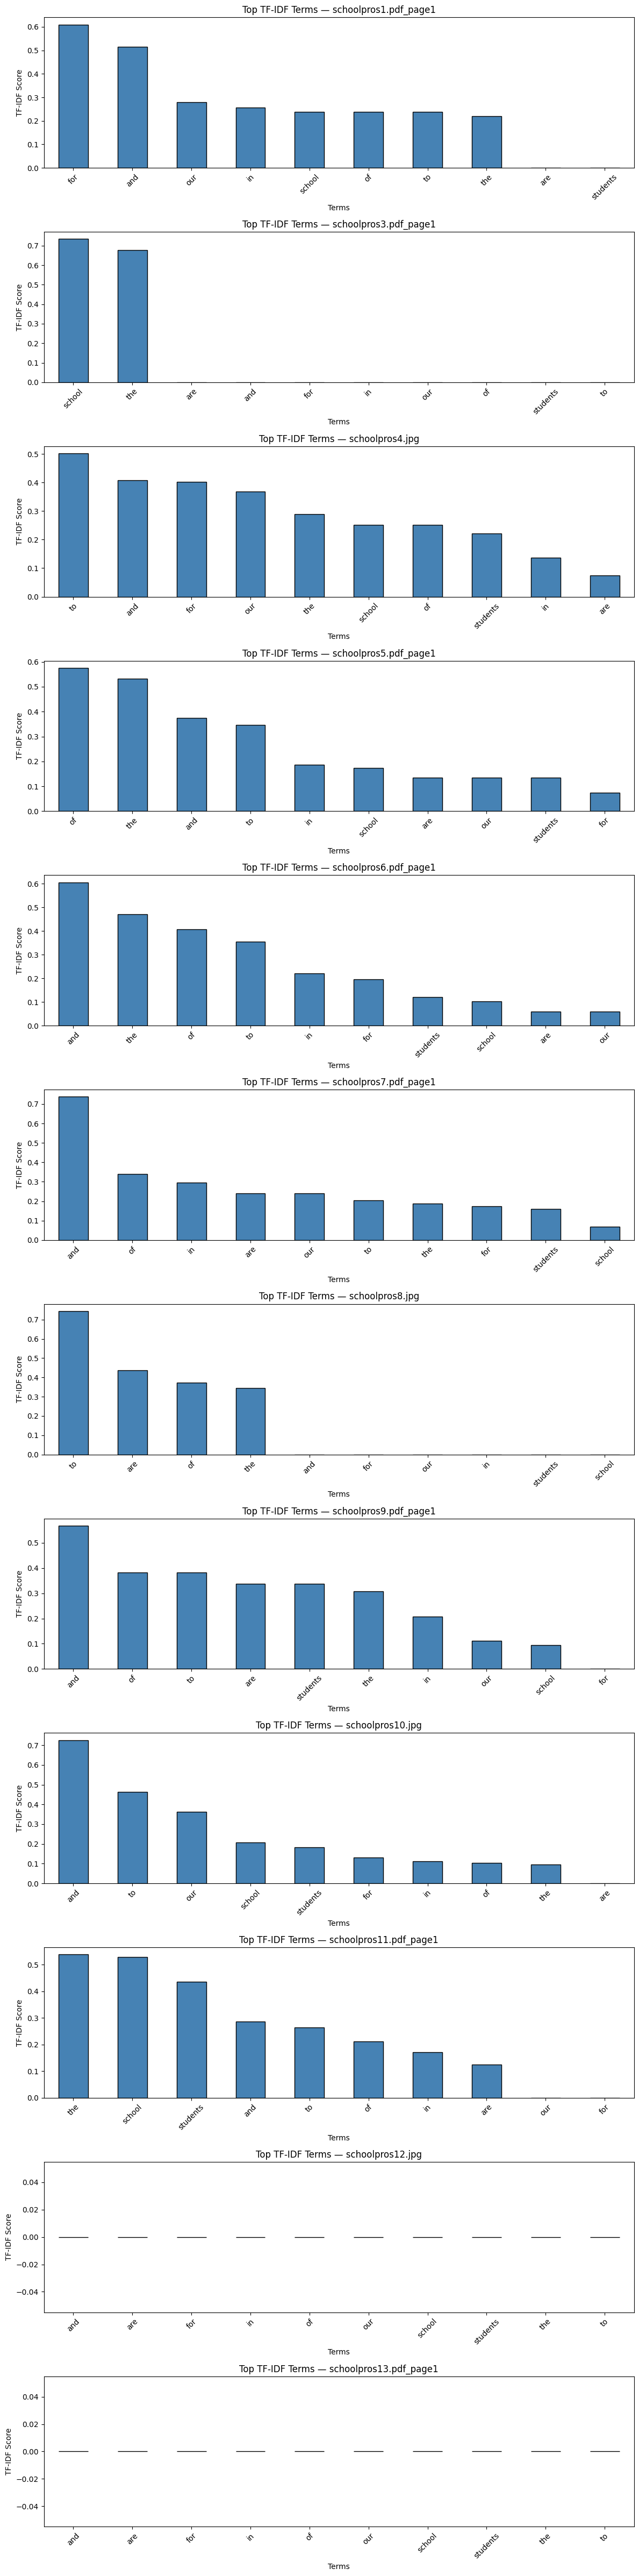

In [16]:
# - Create corpus string required for vectoriser
doc_names = list(corpus_raw.keys()) # convert the keys from corpus raw into list
corpus = list(corpus_raw.values()) # convert the values from corpus raw into a list (of strings)

# - Create vectoriser
vectorizer = TfidfVectorizer( # create vectoriser to turn text to numbers
    max_features=10, # use only 20 most prominent terms
    ngram_range=(1, 2) # one and two word features allowed
)
tfidf_matrix = vectorizer.fit_transform(corpus) # creates matrix repesentative of corpus docs and features

# - Create and Print dataFrame with values
feature_names = vectorizer.get_feature_names_out() # captures the features selected by vectoriser in new variable
tfidf_df = pd.DataFrame( # assign DF class to tfidf_df var
    tfidf_matrix.toarray(), # converts the matrix into array
    columns=feature_names, # column labels set to feature names
    index=doc_names        # row labels set to doc names
)
print("=== TF-IDF SCORES ===") # heading to print
print(tfidf_df.round(3)) #print the DF with results rounded to 3 dec places

# - Identify Top 5 Terms 
print("\n=== TOP TERMS PER DOCUMENT ===") # heading to print
for doc_name in doc_names: # loop throught the docs
    top = tfidf_df.loc[doc_name].sort_values(ascending=False).head(5) # sorts features by TF-IDF score per doc/row - get top 5
    print(f"\n{doc_name}:") #print doc name
    print(top.round(3)) # print result rounded to 3 places

# - Visualise Results 
fig, axes = plt.subplots( # create the fig for graphing
    len(doc_names), # 1 row per doc
    1, # 1 column (stack)
    figsize=(12, 4 * len(doc_names)) #set dimensions
)

for ax, doc_name in zip(axes, doc_names): # pairs axes and docs
    top = tfidf_df.loc[doc_name].sort_values(ascending=False).head(10) # pick top 10 per doc 
    top.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black') #set colours on graph
    ax.set_title(f'Top TF-IDF Terms — {doc_name}', fontsize=12) # set title and font size
    ax.set_xlabel('Terms', fontsize=10) # X axis label and font size 
    ax.set_ylabel('TF-IDF Score', fontsize=10) # y axis label and font size
    ax.tick_params(axis='x', rotation=45) # rotate labels to avoid overlap on display

plt.tight_layout() # auto adjust
plt.show() # display graphs

## Named Entity Recognition

Total entities found: 95
                 document                                             entity  \
0   schoolpros1.pdf_page1                    Regina Mundi College Prospectus   
1   schoolpros1.pdf_page1                                   Wisdom & Courage   
2   schoolpros3.pdf_page1  the Principal 4 Mission Statement 5 Philosophy...   
3   schoolpros3.pdf_page1                                                  9   
4   schoolpros3.pdf_page1                   10 Pastoral Care School Rules 12   
5   schoolpros3.pdf_page1                                     Information 14   
6   schoolpros3.pdf_page1                                                  3   
7         schoolpros4.jpg                                          Principal   
8         schoolpros4.jpg                                           Frincipa   
9         schoolpros4.jpg                                       Yvonne Lucey   
10        schoolpros4.jpg                                          Principal   
11        schoo

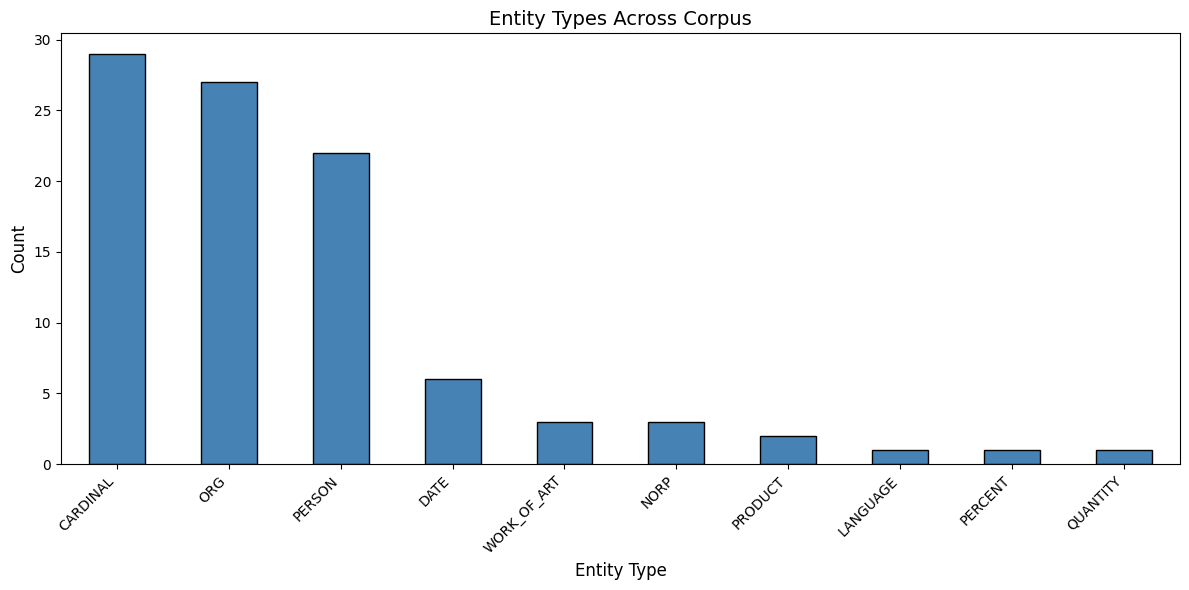

In [17]:
# - Run NER on all docs
all_entities = [] # new empty list for NER

for doc_name, text in corpus_raw.items(): #loop through docs in corpus raw
    doc = nlp(text) # create doc object using spaCy
    for ent in doc.ents: # loops through the entites found
        all_entities.append({ # new dict. for entity info
            'document':  doc_name, # add name of doc with entity
            'entity':    ent.text.strip(), # add name of entity
            'label':     ent.label_, # entity type label
            'description': spacy.explain(ent.label_) # label description
        })

# - Build new dataframe and summarise
entities_df = pd.DataFrame(all_entities) # convert the dict. for entities into a DF
print(f"Total entities found: {len(entities_df)}") #print heading and qty of entities
print(entities_df.head(20)) # print first 20 entities detected in corpus
print("\n=== ENTITIES BY TYPE ===") # print heading
print(entities_df.groupby(['label', 'description']) # group/print qty of each entity type
                 .size() # count
                 .reset_index(name='count') # new DF column for the count
                 .sort_values('count', ascending=False)) # sort highest to lowest
print("\n=== MOST FREQUENT ENTITIES ===") # print heading
print(entities_df.groupby(['entity', 'label']) # now group/print by frequency of entity occurence (not type)
                 .size() # count
                 .reset_index(name='count') # new DF column for the count
                 .sort_values('count', ascending=False) # sort highest to lowest
                 .head(20)) # top 20

# - Visualise Results 
entity_counts = entities_df.groupby('label').size().sort_values(ascending=False) # count and sort entity type high to low

plt.figure(figsize=(12, 6)) # set dimensions
entity_counts.plot(kind='bar', color='steelblue', edgecolor='black') # colours on graphs
plt.title('Entity Types Across Corpus', fontsize=14) # title and font size
plt.xlabel('Entity Type', fontsize=12) # X axis label and font
plt.ylabel('Count', fontsize=12) # y axis label and font
plt.xticks(rotation=45, ha='right') # rotate labels 45 degrees
plt.tight_layout() # auto adjust
plt.show() # and display

# Vision

## Image Quality Assessment

In [19]:
# - Assess image quality

def assess_image_quality(label, img): # create new function for the label string and image array
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # converts from BGR to grayscale for the checks below

    brightness = round(float(np.mean(gray)), 2) # variable for  brightness avg
    contrast = round(float(np.std(gray)), 2) # variable for contrast calc'd using numpy std dev
    blurriness = round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 2) #var for blurriness using this laplacian filter 

    # Resolution: raw pixel dimensions
    h, w = gray.shape # generate tuple of height weight of images
    resolution = f"{w}x{h}" # var for formatted values

    return { # returns results into a dict. containing:
        'document':   label, # pairing document descriptor to label value
        'brightness': brightness, # pairing 'brightness descriptor to brightness value
        'contrast':   contrast, # next pairing
        'blurriness': blurriness, # next pairing
        'resolution': resolution, # next pairing
        'quality_flag': 'NOT OK' if blurriness < 50 or contrast < 20 else 'OK' # built-in quality indicator
    }

quality_results = [assess_image_quality(label, img) for label, img in vision_corpus] # var capturing the quality indicators 
quality_df = pd.DataFrame(quality_results) # create a DF for the quality indicator results

print("=== IMAGE QUALITY REPORT ===") # heading to pringt
print(quality_df.to_string(index=False)) # print the quality results and drop row no. 
print(f"\nPages flagged for quality check: {(quality_df['quality_flag'] == 'CHECK').sum()}") #heading and value to print

=== IMAGE QUALITY REPORT ===
              document  brightness  contrast  blurriness resolution quality_flag
 schoolpros1.pdf_page1      199.26     66.99      475.89  1684x1192           OK
       schoolpros2.jpg      253.28     14.88      160.69  7016x4960       NOT OK
 schoolpros3.pdf_page1      198.13     81.54      720.81  1684x1192           OK
       schoolpros4.jpg      210.82     76.79     1406.11  7016x4960           OK
 schoolpros5.pdf_page1      216.82     62.91     1373.11  1684x1192           OK
 schoolpros6.pdf_page1      214.09     67.39     1572.00  1684x1192           OK
 schoolpros7.pdf_page1      208.50     75.43     1389.87  1684x1192           OK
       schoolpros8.jpg      207.29     76.83     1459.43  7016x4960           OK
 schoolpros9.pdf_page1      206.19     74.04     2100.67  1684x1192           OK
      schoolpros10.jpg      190.61     91.62     1455.73  7016x4960           OK
schoolpros11.pdf_page1      204.31     78.40     1567.24  1684x1192           OK

### Identify Text in the Images

In [20]:
# - Detect and classify regions
def analyse_layout(label, img): # create new function to be applied to label/img 
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # convert BGR to grayscale

    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV) # Threshold to separate content from background

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30, 5)) # create a 30 x 5 matrix to help with structuring - rectangle 
    dilated = cv2.dilate(thresh, kernel, iterations=2) # create a dilated ver of the bin image to expand white regions
    # above lines helps group chars into words, words into lines and cleans up noise
    
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # captures  outter contour detail 

    regions = [] #creates new list to store region data
    h_img, w_img = img.shape[:2] # get height and width of image (image here is a  page)
    page_area = h_img * w_img # determines area - # of pixels

    for cnt in contours: # loop through the contours
        x, y, w, h = cv2.boundingRect(cnt) # determine smallest rectangle around contour
        area = w * h # determine the area
        if area < 0.001 * page_area:  # filter out v small noise contours
            continue 
        aspect = round(w / h, 2) # determine the aspect ration of bounding box for contour
        region_type = 'text_block' if aspect > 3 else 'image_region' # set region type based on aspect to help with identification- wide = likely text block, squarish = likely image
        regions.append({'x': x, 'y': y, 'w': w, 'h': h, # new dict. for the region details pairing up descriptors and values
                        'area': area, 'type': region_type})

    text_blocks  = sum(1 for r in regions if r['type'] == 'text_block') # quantifies text blocks per page
    image_regions = sum(1 for r in regions if r['type'] == 'image_region') # quantifies image regions per page

    return { # returns results into a dict. containing:
        'document':      label, # pairing document descriptor to label value
        'total_regions': len(regions), # next pairing
        'text_blocks':   text_blocks, # next pairing
        'image_regions': image_regions, # next pairing
        'regions':       regions       # # next pairing
    }


layout_results = [analyse_layout(label, img) for label, img in vision_corpus] # loop through corpus to capture layout info
layout_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'regions'} # new dict. with 'regions' removed then coverted to DF
                           for r in layout_results])

print("=== LAYOUT ANALYSIS ===") # heading to be printed
print(layout_df.to_string(index=False)) # display the newly created DF

=== LAYOUT ANALYSIS ===
              document  total_regions  text_blocks  image_regions
 schoolpros1.pdf_page1              4            1              3
       schoolpros2.jpg             11            6              5
 schoolpros3.pdf_page1             17           13              4
       schoolpros4.jpg             25           21              4
 schoolpros5.pdf_page1             17           12              5
 schoolpros6.pdf_page1              4            0              4
 schoolpros7.pdf_page1             11            8              3
       schoolpros8.jpg             25           18              7
 schoolpros9.pdf_page1              3            0              3
      schoolpros10.jpg             24           20              4
schoolpros11.pdf_page1              6            2              4
      schoolpros12.jpg             11            6              5
schoolpros13.pdf_page1             11            7              4


#### Highlighting Identified Text

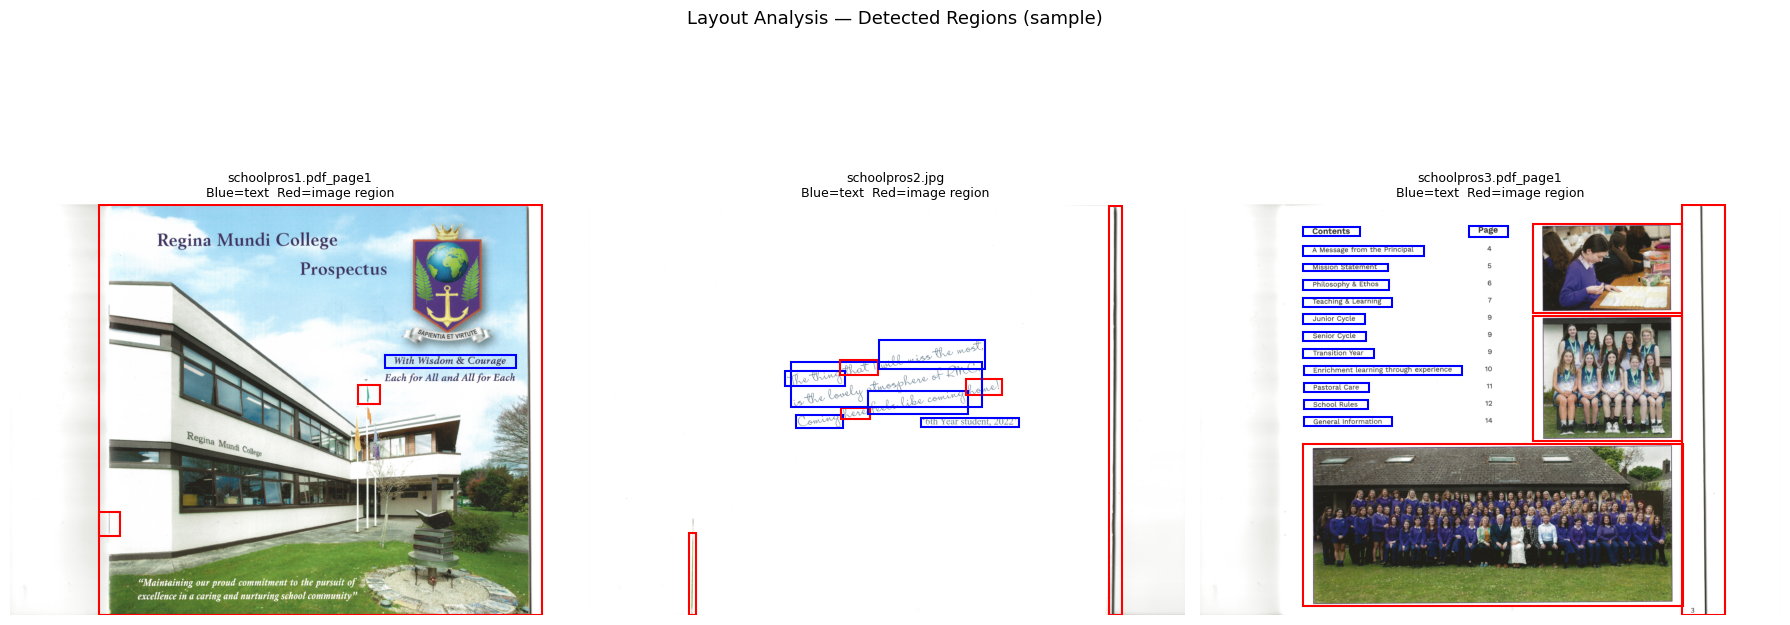

In [21]:
# - Visualise 3 pages as sample

fig, axes = plt.subplots(1, min(3, len(vision_corpus)), figsize=(18, 8)) # create grid 1 row and up to 3 columns with spec'd size
if len(vision_corpus) == 1: axes = [axes] # correction needed for matplotlib

for ax, (label, img), result in zip(axes, vision_corpus[:3], layout_results[:3]): #loop through subplot panels, images and detection results for first 3 and return combo result
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # covert BGR to RGB
    ax.imshow(img_rgb) # draw image into subplot panel
    for region in result['regions']: # inner loop through regions
        colour = 'blue' if region['type'] == 'text_block' else 'red' # sets colouring
        rect = patches.Rectangle( # rectangular image
            (region['x'], region['y']), region['w'], region['h'], # starting top left using width andheight
            linewidth=1.5, edgecolor=colour, facecolor='none' # line thickness / colour
        )
        ax.add_patch(rect) # draws rectangle into subplot
    ax.set_title(f"{label}\nBlue=text  Red=image region", fontsize=9) # title, its fonts and colour
    ax.axis('off') # disable axis display

plt.suptitle("Layout Analysis — Detected Regions (sample)", fontsize=13) # subtitle and font
plt.tight_layout() # auto adjust
plt.show() # display

### Face Detection

In [22]:
# - Attempt to Detect Faces in Images

# Load Haar Cascades Model - bundled with OpenCV
face_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml') #pre-trained model for detecting faces
# Haar Cascade selected based on recommendation here - https://bleedaiacademy.com/5-easy-effective-face-detection-algorithms-in-python/#:~:text=Algorithm%201%3A%20OpenCV%20Haar%20Cascade,the%20same%20haar%20cascade%20technique.

def detect_objects(label, img): # create function
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # convert BGR to grayscale

    faces = face_cascade.detectMultiScale( #use detectmultiscale
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40) # apply default values for scaling, voting and min size threshold
    )
    
    return { # results to dict.
        'document':    label, # 1st pairing 
        'faces_found': len(faces), # etc
        'face_coords':  faces if len(faces) > 0 else [], # store list if face found and store empty list if not
    }


detection_results = [detect_objects(label, img) for label, img in vision_corpus] # runs face detection on the images and store results
detection_df = pd.DataFrame([{k: v for k, v in r.items() # creates a new DF for the results
                               if k not in ['face_coords']} # drops face coords key
                              for r in detection_results]) # list of cleaned dictionaries

print("=== OBJECT / FACE DETECTION RESULTS ===") # print heading
print(detection_df.to_string(index=False)) # convert DF into table and print
print(f"\nTotal faces detected across corpus: {detection_df['faces_found'].sum()}") # print heading and results from table

=== OBJECT / FACE DETECTION RESULTS ===
              document  faces_found
 schoolpros1.pdf_page1            0
       schoolpros2.jpg            0
 schoolpros3.pdf_page1            0
       schoolpros4.jpg            8
 schoolpros5.pdf_page1            1
 schoolpros6.pdf_page1            1
 schoolpros7.pdf_page1            2
       schoolpros8.jpg            4
 schoolpros9.pdf_page1            3
      schoolpros10.jpg            8
schoolpros11.pdf_page1            4
      schoolpros12.jpg            3
schoolpros13.pdf_page1            0

Total faces detected across corpus: 34


#### Highlighting Identified Faces

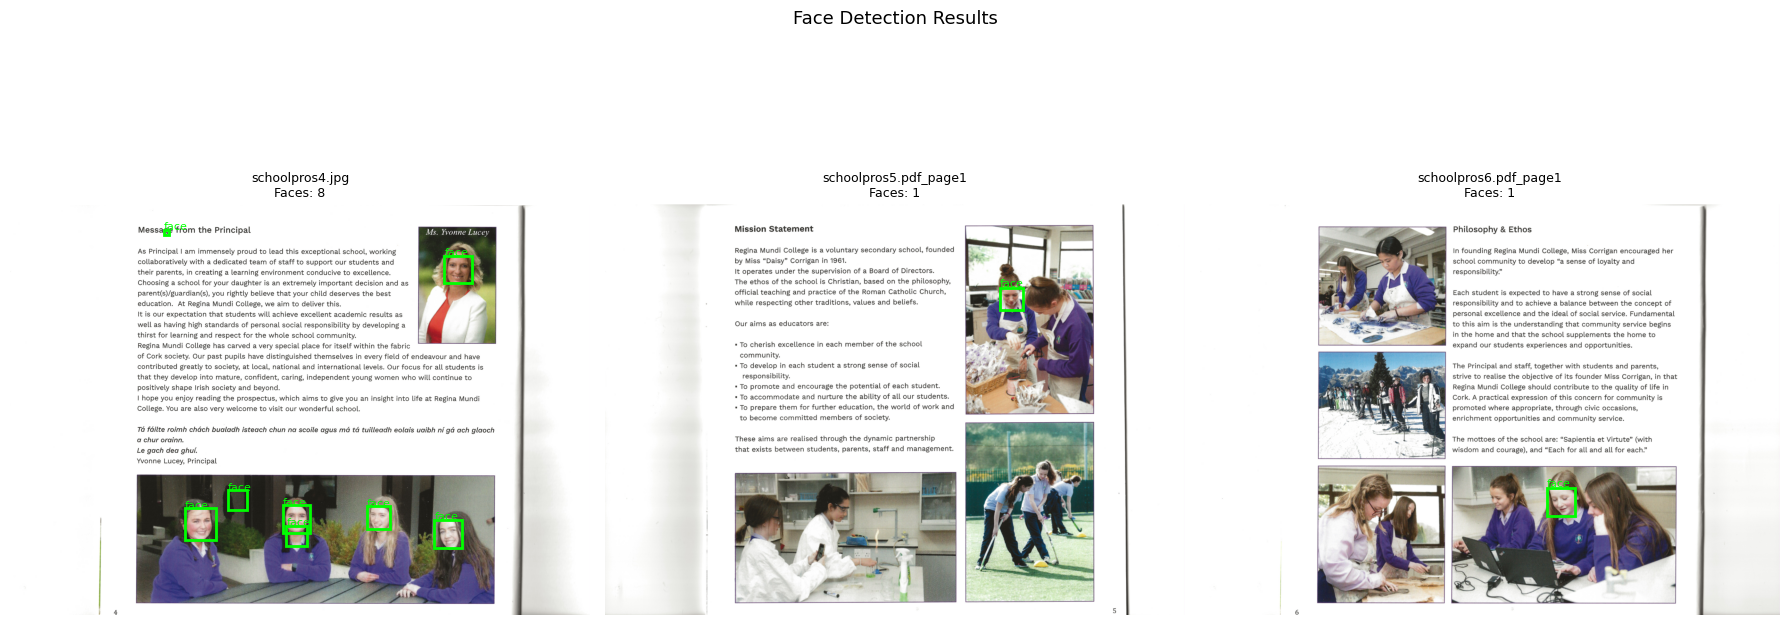

In [29]:
# - Display Detected Faces 

pages_with_detections = [(label, img, result) # new list with 3 element tuple
                         for (label, img), result in zip(vision_corpus, detection_results) # loop through 2 lists in parallel to get label, image and detection result
                         if result['faces_found'] > 0] # only store if face found

if not pages_with_detections: # for pages with no faces
    print("No faces detected across corpus.") # print msg
else: 
    fig, axes = plt.subplots(1, min(3, len(pages_with_detections)), figsize=(18, 8)) # create grid 1 row and up to 3 columns with spec'd size
    if len(pages_with_detections) == 1: axes = [axes] # correction needed for matplotlib

    for ax, (label, img, result) in zip(axes, pages_with_detections[:3]): # unpack the subplot to draw for first 3
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # convert BGR to RGB
        ax.imshow(img_rgb) #draw image

        for (x, y, w, h) in result['face_coords']: # loop through face coordinate results
            rect = patches.Rectangle((x, y), w, h, # create rectangle around the face based on coordinates
                                      linewidth=2, edgecolor='lime', facecolor='none') # line thickness + colour
            ax.add_patch(rect) # actually draw the rectangle created
            ax.text(x, y - 5, 'face', color='lime', fontsize=8) # title and font to accompany rectangle

        ax.set_title(f"{label}\nFaces: {result['faces_found']}", fontsize=9) # title and font for results
        ax.axis('off') # disable axes

    plt.suptitle("Face Detection Results", fontsize=13) # print sub-heading
    plt.tight_layout() #auto adjust
    plt.show() #display

# Multi-modal

### Collate Results from NLP and Vision Pipelines

In [35]:
# - Pull together pipeline results

def get_nlp_summary(doc_name): # new function for NLP report details
    
    # - TF-IDF top 5 keywords
    tfidf_keywords = [] # new list
    if doc_name in tfidf_df.index: # check the doc exists in the TF-IDF results
        row = tfidf_df.loc[doc_name] # get the row for this doc
        tfidf_keywords = row.sort_values(ascending=False).head(5) # sort by score, take top 5
        tfidf_keywords = [term for term in tfidf_keywords.index if row[term] > 0] # keep only terms with score > 0

    # - NER named entities
    ner_entities = [] # new list for NER
    if not entities_df.empty and 'document' in entities_df.columns: # DF not empty with column called 'document'
        relevant_types = ['CARDINAL', 'ORG', 'PERSON', 'DATE'] # setting values based on NER analysis from earlier iteration in pipeline build
        doc_ents = entities_df[ #create a list from the DF
            (entities_df['document'] == doc_name) & # keeping rows when document name equals document column value AND
            (entities_df['label'].isin(relevant_types)) # when rows when entity type matches relevant types
        ]
        #ner_entities = doc_ents['entity'].tolist()[:8] # convert column to list- limit to first 8 entries
        
        ents_list = doc_ents['entity'].tolist() # Convert column to list
        counts = Counter(ents_list) # Count frequencies
        ner_entities = [ent for ent, freq in counts.most_common(8)] # get top 8 

    return tfidf_keywords, ner_entities # return lists


def get_vision_summary(doc_name): # new function for Vision report details

    # TO BE DELETED """Pull quality, layout and face detection results for a given document."""
    # TO BE DELETED Strip page suffix to match JPG filenames (e.g. 'schoolpros2.jpg')
    # TO BE DELETED PDF pages are stored as 'schoolpros1.pdf_page1' so we match on startswith
    base = doc_name  # doc_name from corpus_raw keys e.g. 'schoolpros2.jpg' or 'schoolpros1.pdf_page1'

    # - Image quality metrics
    doc_quality = quality_df[quality_df['document'].str.startswith(base.split('_page')[0])] #new DF with rows filtered on doc name ex. page no.
    flagged     = int((doc_quality['quality_flag'] == 'NOT OK').sum()) if not doc_quality.empty else 0 # sum rows with NOT OK quality 
    avg_brightness = round(doc_quality['brightness'].mean(), 2) if not doc_quality.empty else 'N/A' # calc average brightness for the rows returned
    avg_blurriness = round(doc_quality['blurriness'].mean(), 2) if not doc_quality.empty else 'N/A' # calc average blur for the rows returned

    # - Image layout metrics
    doc_layout       = layout_df[layout_df['document'].str.startswith(base.split('_page')[0])] # next DF with rows filtered on doc name ex. page no.
    total_text       = int(doc_layout['text_blocks'].sum())   if not doc_layout.empty else 0 # sum rows for text
    total_images     = int(doc_layout['image_regions'].sum()) if not doc_layout.empty else 0 # sum rows for images

    # - Images faces found
    doc_detections = detection_df[detection_df['document'].str.startswith(base.split('_page')[0])] # next DF to be used for face detection metrics 
    total_faces    = int(doc_detections['faces_found'].sum()) if not doc_detections.empty else 0 # sum rows for faces found

    return flagged, avg_brightness, avg_blurriness, total_text, total_images, total_faces # return integer values of metrics
    

In [41]:
# - Print results to screen and to output .txt file

report_lines= [] # new list so an output txt file can be generated from it
line = "CA2 Multi-Modal Analysis Report — L00007202" # report title
print(line) # display on screen
report_lines.append(line) # append to output txt report
line = "=" * 60 # framing lines 
print(line) # display on screen...this line is repeated throughout this section and has same meaning
report_lines.append(line) # append to output file...this line is repeated throughout this section and has same meaning

for doc_name in doc_names: # loop through doc list

    tfidf_keywords, ner_entities = get_nlp_summary(doc_name) # run nlp_summary to get/store results
    flagged, avg_brightness, avg_blurriness, \
        total_text, total_images, total_faces = get_vision_summary(doc_name) # get the 6 values as variables

    line = f"\nDOCUMENT : {doc_name}" # line for with doc name - results below under this as heading
    print(line)
    report_lines.append(line)
    line = "=" * 60 # formatting 
    print(line)
    report_lines.append(line)


    # - NLP related results
    line = "  [NLP]" # line with heading...repeated for each section
    print(line)
    report_lines.append(line)
    line = f"  Top Keywords   : {', '.join(tfidf_keywords) if tfidf_keywords else 'None found'}" # fstring of keywords founds
    print(line)
    report_lines.append(line)
    line = f"  Named Entities : {', '.join(ner_entities)   if ner_entities   else 'None found'}" # NER
    print(line)
    report_lines.append(line)

    # - Vision related results
    line = "  [VISION]"
    print(line)
    report_lines.append(line)
    line = f"  Avg Brightness : {avg_brightness}  |  Avg Blurriness : {avg_blurriness}" # yada yada 
    print(line)
    report_lines.append(line)
    line = f"  Quality Flags  : {flagged} page(s) flagged as NOT OK"
    print(line)
    report_lines.append(line)
    line = f"  Layout Regions : {total_text} text block(s)  |  {total_images} image region(s)"
    print(line)
    report_lines.append(line)
    line = f"  Faces Detected : {total_faces}"
    print(line)
    report_lines.append(line)

    # - Auto-generated interpretation of NLP and Vision combined with descriptors based on conditions of each page
    line = "  [INTERPRETATION]"
    print(line)
    report_lines.append(line)
    if total_faces > 0 and total_images > total_text:
        line = f"  People-focused page — {total_faces} face(s) detected in an image-heavy layout."
        print(line)
        report_lines.append(line)
    elif total_text > total_images:
        line = "  Text-heavy page — likely information, curriculum or policy focused."
        print(line)
        report_lines.append(line)
    else:
        line = "  Mixed layout — balance of text and image content."
        print(line)
        report_lines.append(line)

    if flagged > 0:
        line = f"  Note: {flagged} page(s) had low quality scores — OCR accuracy may be affected."
        print(line)
        report_lines.append(line)

    if tfidf_keywords:
        line = f"  Key themes suggested by TF-IDF: {', '.join(tfidf_keywords[:3])}." # top 3 keywords to help with understandng of the doc/page
        print(line)
        report_lines.append(line)

line = "\n" + "=" * 60
print(line)
report_lines.append(line)
line = "   END OF REPORT"
print(line)
report_lines.append(line)
line = "=" * 60
print(line)
report_lines.append(line)

output_text = "\n".join(report_lines)

with open("CA2 Output Report.txt", "w", encoding="utf-8") as f:
    f.write(output_text)


CA2 Multi-Modal Analysis Report — L00007202

DOCUMENT : schoolpros1.pdf_page1
  [NLP]
  Top Keywords   : for, and, our, in, school
  Named Entities : Regina Mundi College Prospectus, Wisdom & Courage
  [VISION]
  Avg Brightness : 199.26  |  Avg Blurriness : 475.89
  Quality Flags  : 0 page(s) flagged as NOT OK
  Layout Regions : 1 text block(s)  |  3 image region(s)
  Faces Detected : 0
  [INTERPRETATION]
  Mixed layout — balance of text and image content.
  Key themes suggested by TF-IDF: for, and, our.

DOCUMENT : schoolpros3.pdf_page1
  [NLP]
  Top Keywords   : school, the
  Named Entities : the Principal 4 Mission Statement 5 Philosophy & Ethos, 9, 10 Pastoral Care School Rules 12, 3
  [VISION]
  Avg Brightness : 198.13  |  Avg Blurriness : 720.81
  Quality Flags  : 0 page(s) flagged as NOT OK
  Layout Regions : 13 text block(s)  |  4 image region(s)
  Faces Detected : 0
  [INTERPRETATION]
  Text-heavy page — likely information, curriculum or policy focused.
  Key themes suggested 

# Final Output

An output file called "CA2 Output Report.txt" has been generated for review. It's contents will match what is shown on screen above.

### END